In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

n = 50000

cities_states = {
    'Mumbai': 'Maharashtra', 'Pune': 'Maharashtra', 'Nagpur': 'Maharashtra',
    'Bengaluru': 'Karnataka', 'Mysuru': 'Karnataka', 'Hubli': 'Karnataka',
    'Delhi': 'Delhi', 'Noida': 'Delhi', 'Gurugram': 'Delhi',
    'Hyderabad': 'Telangana', 'Warangal': 'Telangana',
    'Chennai': 'Tamil Nadu', 'Coimbatore': 'Tamil Nadu', 'Madurai': 'Tamil Nadu',
    'Kolkata': 'West Bengal', 'Howrah': 'West Bengal',
    'Ahmedabad': 'Gujarat', 'Surat': 'Gujarat', 'Vadodara': 'Gujarat',
    'Jaipur': 'Rajasthan', 'Jodhpur': 'Rajasthan',
    'Lucknow': 'Uttar Pradesh', 'Kanpur': 'Uttar Pradesh', 'Agra': 'Uttar Pradesh',
    'Bhopal': 'Madhya Pradesh', 'Indore': 'Madhya Pradesh',
    'Patna': 'Bihar', 'Ranchi': 'Jharkhand', 'Bhubaneswar': 'Odisha',
}

cities = list(cities_states.keys())
payment_methods = ['UPI', 'Debit Card', 'Credit Card', 'Net Banking', 'Mobile Wallet']
payment_weights = [0.45, 0.20, 0.18, 0.10, 0.07]
merchant_categories = [
    'Food & Dining', 'Shopping', 'Travel', 'Entertainment',
    'Utilities', 'Healthcare', 'Education', 'Fuel',
    'Groceries', 'Electronics', 'Recharge', 'Insurance'
]
banks = [
    'HDFC Bank', 'SBI', 'ICICI Bank', 'Axis Bank', 'Kotak Bank',
    'Yes Bank', 'Punjab National Bank', 'Bank of Baroda',
    'PhonePe', 'Google Pay', 'Paytm', 'Amazon Pay'
]
device_types = ['Android Mobile', 'iPhone', 'Desktop/Laptop', 'Tablet']
device_weights = [0.55, 0.20, 0.20, 0.05]
age_groups = ['18-25', '26-35', '36-45', '46-55', '55+']
age_weights = [0.25, 0.35, 0.22, 0.12, 0.06]

city_col = np.random.choice(cities, n)
state_col = [cities_states[c] for c in city_col]
payment_method_col = np.random.choice(payment_methods, n, p=payment_weights)
merchant_col = np.random.choice(merchant_categories, n)
bank_col = np.random.choice(banks, n)
device_col = np.random.choice(device_types, n, p=device_weights)
age_col = np.random.choice(age_groups, n, p=age_weights)

amounts = []
for pm in payment_method_col:
    if pm == 'UPI':
        amounts.append(round(np.random.lognormal(6, 1.2), 2))
    elif pm == 'Credit Card':
        amounts.append(round(np.random.lognormal(7.5, 1.0), 2))
    elif pm == 'Debit Card':
        amounts.append(round(np.random.lognormal(6.5, 1.1), 2))
    elif pm == 'Net Banking':
        amounts.append(round(np.random.lognormal(8, 0.9), 2))
    else:
        amounts.append(round(np.random.lognormal(5.5, 1.3), 2))
amounts = np.clip(amounts, 1, 500000)

start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)
timestamps = [start_date + timedelta(
    seconds=random.randint(0, int((end_date - start_date).total_seconds()))
) for _ in range(n)]

hours = [t.hour for t in timestamps]
months = [t.month for t in timestamps]
days = [t.strftime('%A') for t in timestamps]

fraud_labels = []
fraud_scores = []

for i in range(n):
    score = 0
    if hours[i] >= 23 or hours[i] <= 4:
        score += 35
    elif hours[i] >= 21:
        score += 15
    if payment_method_col[i] == 'Net Banking':
        score += 20
    elif payment_method_col[i] == 'Credit Card':
        score += 15
    if amounts[i] > 50000:
        score += 25
    elif amounts[i] > 20000:
        score += 15
    elif amounts[i] > 10000:
        score += 8
    if merchant_col[i] in ['Electronics', 'Travel', 'Entertainment']:
        score += 10
    if device_col[i] == 'Desktop/Laptop':
        score += 8
    if age_col[i] == '55+':
        score += 12
    elif age_col[i] == '18-25':
        score += 5
    score += random.randint(-10, 10)
    score = max(0, min(100, score))
    fraud_scores.append(score)
    fraud_prob = score / 400
    fraud_labels.append(1 if random.random() < fraud_prob else 0)

investigation_status = []
for f, score in zip(fraud_labels, fraud_scores):
    if f == 1:
        investigation_status.append(np.random.choice(
            ['Confirmed Fraud', 'Under Investigation', 'Resolved'],
            p=[0.55, 0.30, 0.15]
        ))
    elif score > 60:
        investigation_status.append(np.random.choice(
            ['Flagged', 'Under Investigation', 'Cleared'],
            p=[0.50, 0.30, 0.20]
        ))
    elif score > 40:
        investigation_status.append('Suspicious')
    else:
        investigation_status.append('Clean')

df = pd.DataFrame({
    'transaction_id': [f'TXN{str(i+1).zfill(6)}' for i in range(n)],
    'transaction_date': [t.strftime('%Y-%m-%d') for t in timestamps],
    'transaction_time': [t.strftime('%H:%M:%S') for t in timestamps],
    'hour': hours,
    'month': months,
    'day_of_week': days,
    'payment_method': payment_method_col,
    'transaction_amount': amounts,
    'merchant_category': merchant_col,
    'city': city_col,
    'state': state_col,
    'bank_provider': bank_col,
    'device_type': device_col,
    'customer_age_group': age_col,
    'fraud_risk_score': fraud_scores,
    'fraud_label': fraud_labels,
    'investigation_status': investigation_status,
})

df.to_csv('../data/india_payments_raw.csv', index=False)
print("✅ Dataset Generated Successfully!")
print(f"Total transactions: {len(df):,}")
print(f"Fraudulent: {df['fraud_label'].sum():,} ({df['fraud_label'].mean()*100:.2f}%)")
print(f"Cities: {df['city'].nunique()} | States: {df['state'].nunique()}")
print(f"Date range: {df['transaction_date'].min()} to {df['transaction_date'].max()}")
print("\nInvestigation Status:")
print(df['investigation_status'].value_counts())
df.head()

✅ Dataset Generated Successfully!
Total transactions: 50,000
Fraudulent: 2,707 (5.41%)
Cities: 29 | States: 13
Date range: 2023-01-01 to 2024-12-30

Investigation Status:
investigation_status
Clean                  39408
Suspicious              6592
Confirmed Fraud         1493
Under Investigation     1208
Flagged                  629
Resolved                 407
Cleared                  263
Name: count, dtype: int64


,transaction_id,transaction_date,transaction_time,hour,month,day_of_week,payment_method,transaction_amount,merchant_category,city,state,bank_provider,device_type,customer_age_group,fraud_risk_score,fraud_label,investigation_status
0,TXN000001,2024-05-11,15:46:46,15,5,Saturday,UPI,456.96,Recharge,Delhi,Delhi,ICICI Bank,Android Mobile,36-45,7,0,Clean
1,TXN000002,2023-03-28,11:21:41,11,3,Tuesday,Debit Card,744.47,Insurance,Jaipur,Rajasthan,Yes Bank,Android Mobile,18-25,15,0,Clean
2,TXN000003,2023-01-20,10:14:03,10,1,Friday,Credit Card,1895.53,Recharge,Bhubaneswar,Odisha,Punjab National Bank,Android Mobile,18-25,29,0,Clean
3,TXN000004,2024-07-29,23:30:11,23,7,Monday,Credit Card,2079.97,Travel,Kolkata,West Bengal,Punjab National Bank,Tablet,26-35,63,0,Flagged
4,TXN000005,2023-08-02,14:55:05,14,8,Wednesday,Debit Card,1508.36,Recharge,Warangal,Telangana,HDFC Bank,iPhone,36-45,5,0,Clean


In [2]:
print("="*55)
print("DATA CLEANING")
print("="*55)

print(f"Shape before cleaning: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

df = df.drop_duplicates()

# Amount categories in Indian Rupees
df['amount_category'] = pd.cut(
    df['transaction_amount'],
    bins=[0, 500, 2000, 10000, 50000, float('inf')],
    labels=['Micro (0-500)', 'Small (500-2K)', 
            'Medium (2K-10K)', 'Large (10K-50K)', 'Very Large (50K+)']
)

# Risk categories
df['risk_category'] = pd.cut(
    df['fraud_risk_score'],
    bins=[0, 30, 60, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Time categories
df['time_category'] = pd.cut(
    df['hour'],
    bins=[-1, 6, 12, 18, 23],
    labels=['Night (12AM-6AM)', 'Morning (6AM-12PM)', 
            'Afternoon (12PM-6PM)', 'Evening (6PM-12AM)']
)

df.to_csv('../data/india_payments_clean.csv', index=False)

print(f"\nShape after cleaning: {df.shape}")
print(f"New columns added: amount_category, risk_category, time_category")
print("\n✅ Data Cleaning Complete!")
df.head()

DATA CLEANING
Shape before cleaning: (50000, 17)
Missing values: 0
Duplicates: 0

Shape after cleaning: (50000, 20)
New columns added: amount_category, risk_category, time_category

✅ Data Cleaning Complete!


,transaction_id,transaction_date,transaction_time,hour,month,day_of_week,payment_method,transaction_amount,merchant_category,city,state,bank_provider,device_type,customer_age_group,fraud_risk_score,fraud_label,investigation_status,amount_category,risk_category,time_category
0,TXN000001,2024-05-11,15:46:46,15,5,Saturday,UPI,456.96,Recharge,Delhi,Delhi,ICICI Bank,Android Mobile,36-45,7,0,Clean,Micro (0-500),Low Risk,Afternoon (12PM-6PM)
1,TXN000002,2023-03-28,11:21:41,11,3,Tuesday,Debit Card,744.47,Insurance,Jaipur,Rajasthan,Yes Bank,Android Mobile,18-25,15,0,Clean,Small (500-2K),Low Risk,Morning (6AM-12PM)
2,TXN000003,2023-01-20,10:14:03,10,1,Friday,Credit Card,1895.53,Recharge,Bhubaneswar,Odisha,Punjab National Bank,Android Mobile,18-25,29,0,Clean,Small (500-2K),Low Risk,Morning (6AM-12PM)
3,TXN000004,2024-07-29,23:30:11,23,7,Monday,Credit Card,2079.97,Travel,Kolkata,West Bengal,Punjab National Bank,Tablet,26-35,63,0,Flagged,Medium (2K-10K),High Risk,Evening (6PM-12AM)
4,TXN000005,2023-08-02,14:55:05,14,8,Wednesday,Debit Card,1508.36,Recharge,Warangal,Telangana,HDFC Bank,iPhone,36-45,5,0,Clean,Small (500-2K),Low Risk,Afternoon (12PM-6PM)


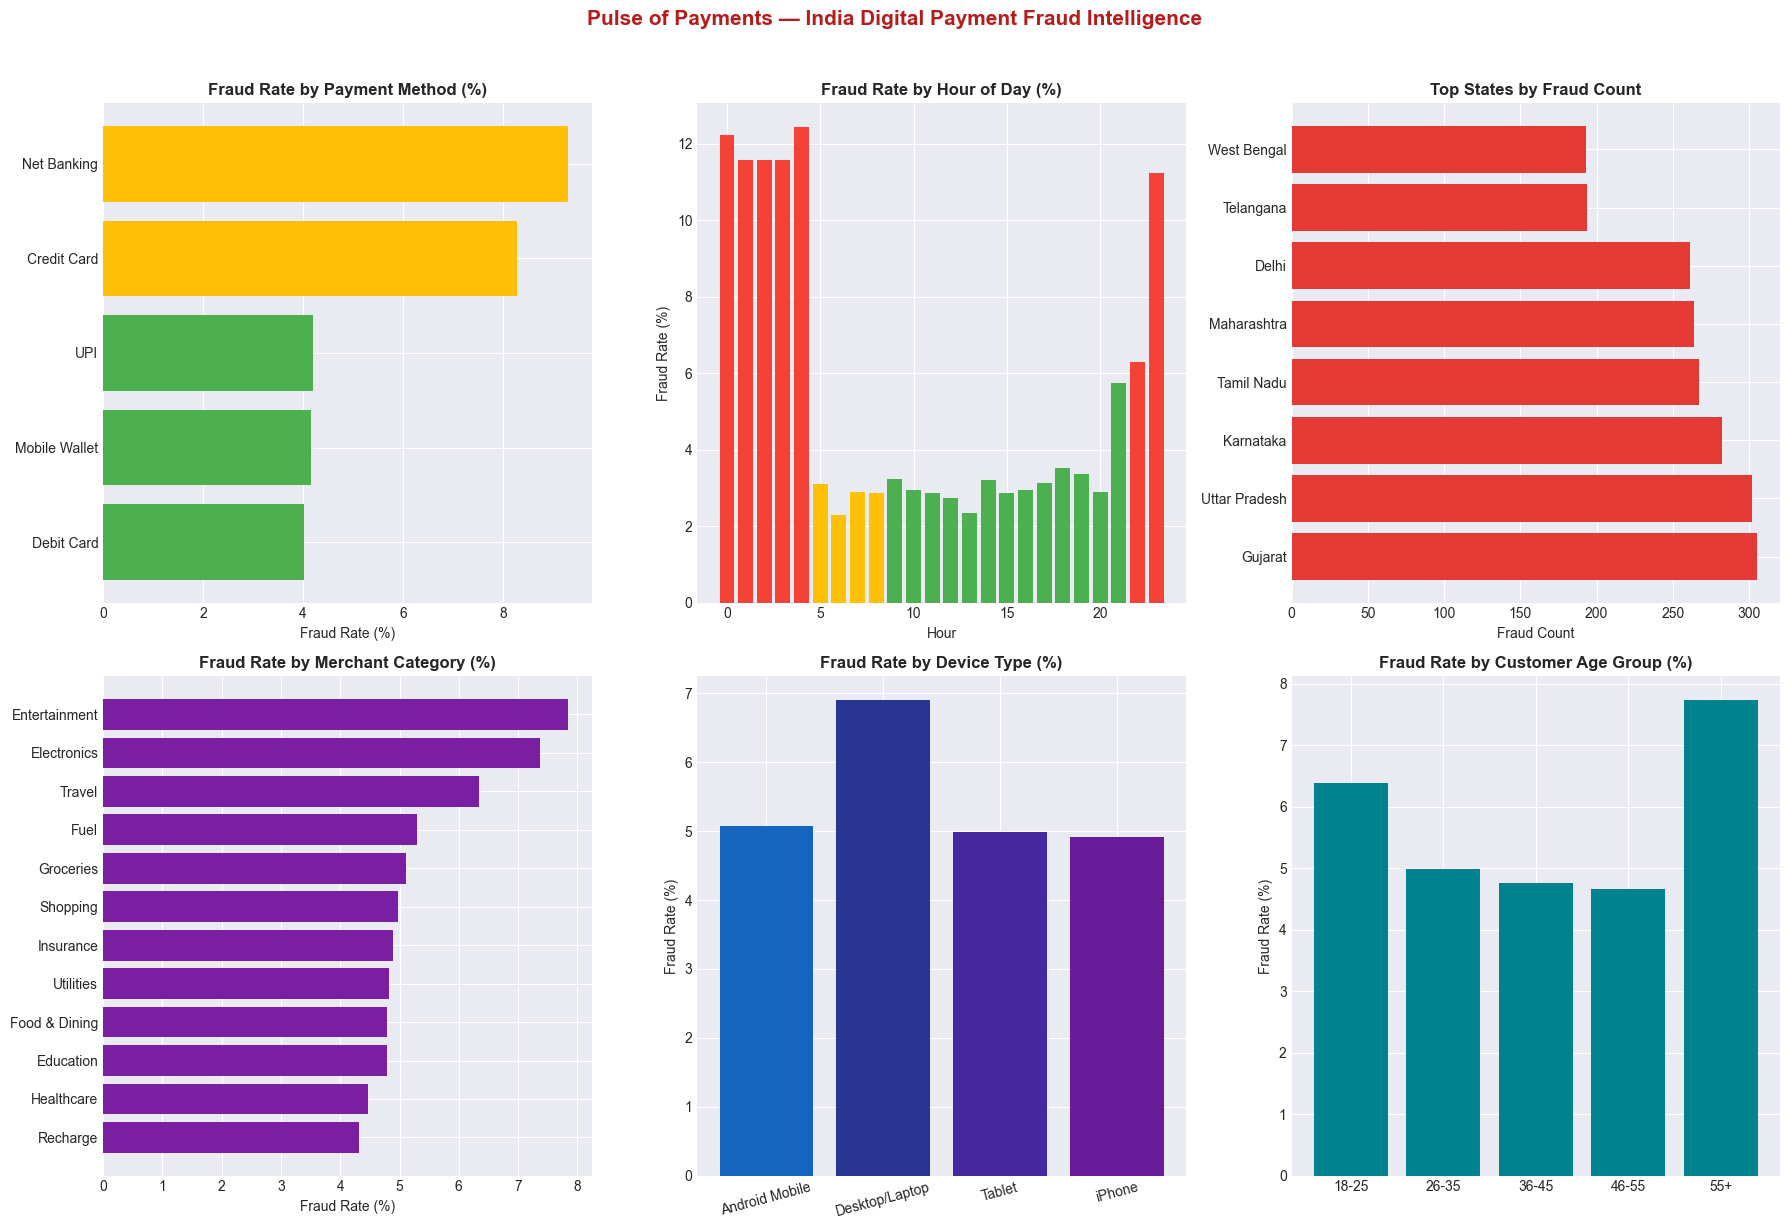

✅ Chart 1 saved!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Chart 1 - Fraud by payment method
fraud_by_pm = df.groupby('payment_method')['fraud_label'].agg(['sum','count'])
fraud_by_pm['rate'] = fraud_by_pm['sum']/fraud_by_pm['count']*100
fraud_by_pm = fraud_by_pm.sort_values('rate', ascending=True)
colors = ['#4CAF50' if r < 5 else '#FFC107' if r < 10 else '#F44336' 
          for r in fraud_by_pm['rate']]
axes[0,0].barh(fraud_by_pm.index, fraud_by_pm['rate'], color=colors)
axes[0,0].set_title('Fraud Rate by Payment Method (%)', fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Fraud Rate (%)')

# Chart 2 - Fraud by hour
hourly = df.groupby('hour')['fraud_label'].agg(['sum','count'])
hourly['rate'] = hourly['sum']/hourly['count']*100
hour_colors = ['#F44336' if h >= 22 or h <= 4 else '#FFC107' if h <= 8 else '#4CAF50' 
               for h in hourly.index]
axes[0,1].bar(hourly.index, hourly['rate'], color=hour_colors)
axes[0,1].set_title('Fraud Rate by Hour of Day (%)', fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Fraud Rate (%)')

# Chart 3 - Top states by fraud
state_fraud = df.groupby('state')['fraud_label'].agg(['sum','count'])
state_fraud['rate'] = state_fraud['sum']/state_fraud['count']*100
state_fraud = state_fraud.nlargest(8, 'sum')
axes[0,2].barh(state_fraud.index, state_fraud['sum'], color='#E53935')
axes[0,2].set_title('Top States by Fraud Count', fontweight='bold', fontsize=12)
axes[0,2].set_xlabel('Fraud Count')

# Chart 4 - Fraud by merchant category
merch_fraud = df.groupby('merchant_category')['fraud_label'].agg(['sum','count'])
merch_fraud['rate'] = merch_fraud['sum']/merch_fraud['count']*100
merch_fraud = merch_fraud.sort_values('rate', ascending=True)
axes[1,0].barh(merch_fraud.index, merch_fraud['rate'], color='#7B1FA2')
axes[1,0].set_title('Fraud Rate by Merchant Category (%)', fontweight='bold', fontsize=12)
axes[1,0].set_xlabel('Fraud Rate (%)')

# Chart 5 - Fraud by device type
device_fraud = df.groupby('device_type')['fraud_label'].agg(['sum','count'])
device_fraud['rate'] = device_fraud['sum']/device_fraud['count']*100
axes[1,1].bar(device_fraud.index, device_fraud['rate'], 
              color=['#1565C0','#283593','#4527A0','#6A1B9A'])
axes[1,1].set_title('Fraud Rate by Device Type (%)', fontweight='bold', fontsize=12)
axes[1,1].set_ylabel('Fraud Rate (%)')
axes[1,1].tick_params(axis='x', rotation=15)

# Chart 6 - Fraud by age group
age_fraud = df.groupby('customer_age_group')['fraud_label'].agg(['sum','count'])
age_fraud['rate'] = age_fraud['sum']/age_fraud['count']*100
axes[1,2].bar(age_fraud.index, age_fraud['rate'], color='#00838F')
axes[1,2].set_title('Fraud Rate by Customer Age Group (%)', fontweight='bold', fontsize=12)
axes[1,2].set_ylabel('Fraud Rate (%)')

plt.suptitle('Pulse of Payments — India Digital Payment Fraud Intelligence', 
             fontsize=15, fontweight='bold', color='#B71C1C', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/chart1_fraud_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

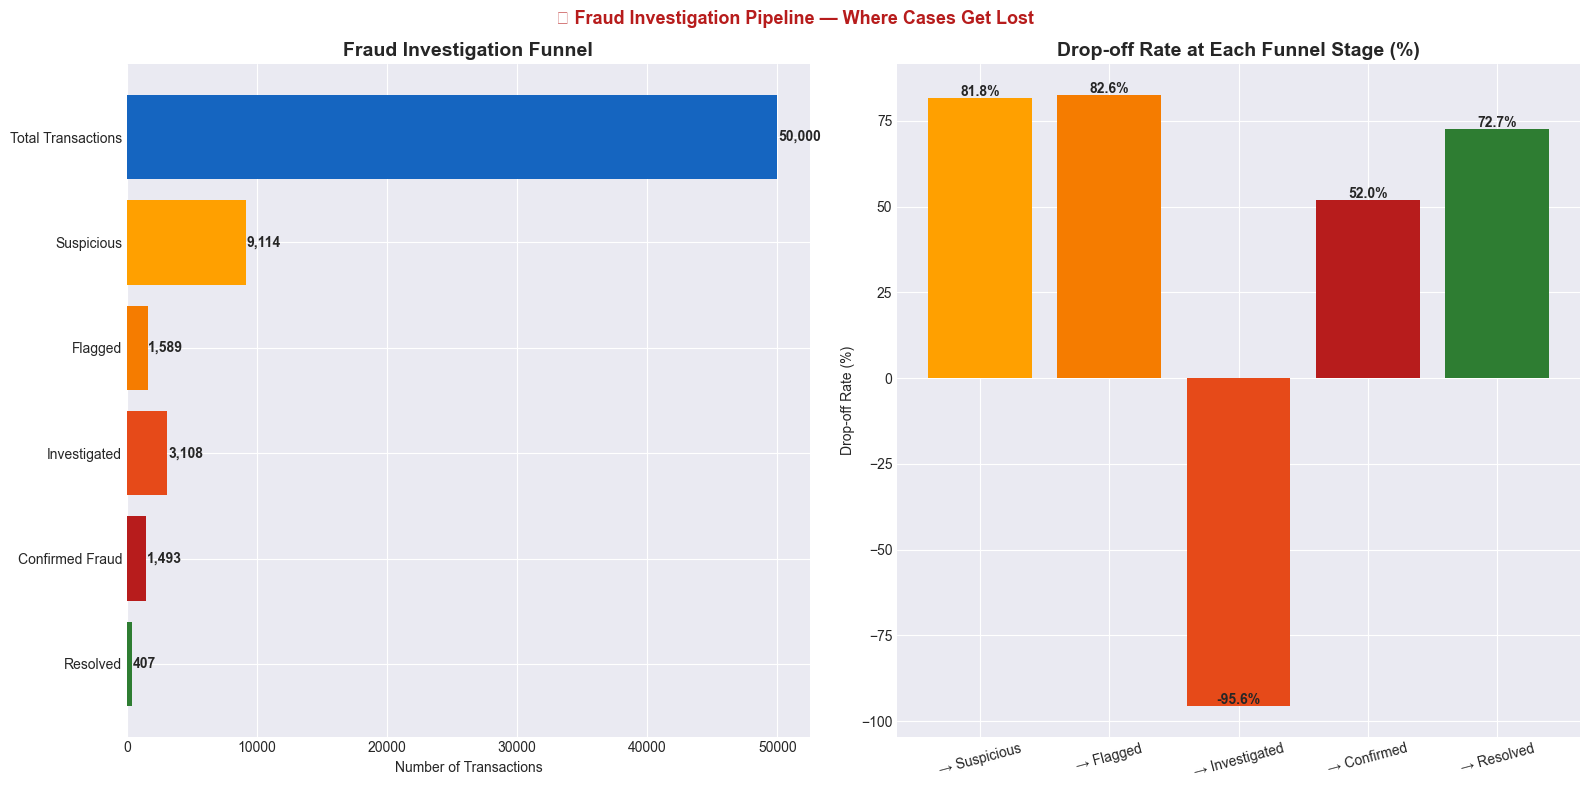

✅ Funnel Chart saved!

Funnel Summary:
  Total Transactions: 50,000 (100.0%)
  Suspicious: 9,114 (18.2%)
  Flagged: 1,589 (3.2%)
  Investigated: 3,108 (6.2%)
  Confirmed Fraud: 1,493 (3.0%)
  Resolved: 407 (0.8%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Funnel data
total = len(df)
suspicious = len(df[df['fraud_risk_score'] > 40])
flagged = len(df[df['fraud_risk_score'] > 60])
investigated = len(df[df['investigation_status'].isin(['Under Investigation', 'Confirmed Fraud', 'Resolved'])])
confirmed = len(df[df['investigation_status'] == 'Confirmed Fraud'])
resolved = len(df[df['investigation_status'] == 'Resolved'])

funnel_stages = ['Total Transactions', 'Suspicious', 'Flagged', 
                 'Investigated', 'Confirmed Fraud', 'Resolved']
funnel_values = [total, suspicious, flagged, investigated, confirmed, resolved]
funnel_colors = ['#1565C0', '#FFA000', '#F57C00', '#E64A19', '#B71C1C', '#2E7D32']

# Funnel chart
bars = axes[0].barh(funnel_stages[::-1], funnel_values[::-1], color=funnel_colors[::-1])
axes[0].set_title('Fraud Investigation Funnel', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Number of Transactions')
for bar, val in zip(bars, funnel_values[::-1]):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontweight='bold', fontsize=10)

# Drop-off rates
dropoffs = []
for i in range(1, len(funnel_values)):
    rate = (1 - funnel_values[i]/funnel_values[i-1]) * 100
    dropoffs.append(rate)

drop_labels = ['→ Suspicious', '→ Flagged', '→ Investigated', 
               '→ Confirmed', '→ Resolved']
colors_drop = ['#FFA000', '#F57C00', '#E64A19', '#B71C1C', '#2E7D32']
bars2 = axes[1].bar(drop_labels, dropoffs, color=colors_drop)
axes[1].set_title('Drop-off Rate at Each Funnel Stage (%)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Drop-off Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, dropoffs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('🔍 Fraud Investigation Pipeline — Where Cases Get Lost', 
             fontsize=13, fontweight='bold', color='#B71C1C')
plt.tight_layout()
plt.savefig('../outputs/chart2_investigation_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Funnel Chart saved!")
print(f"\nFunnel Summary:")
for stage, val in zip(funnel_stages, funnel_values):
    print(f"  {stage}: {val:,} ({val/total*100:.1f}%)")

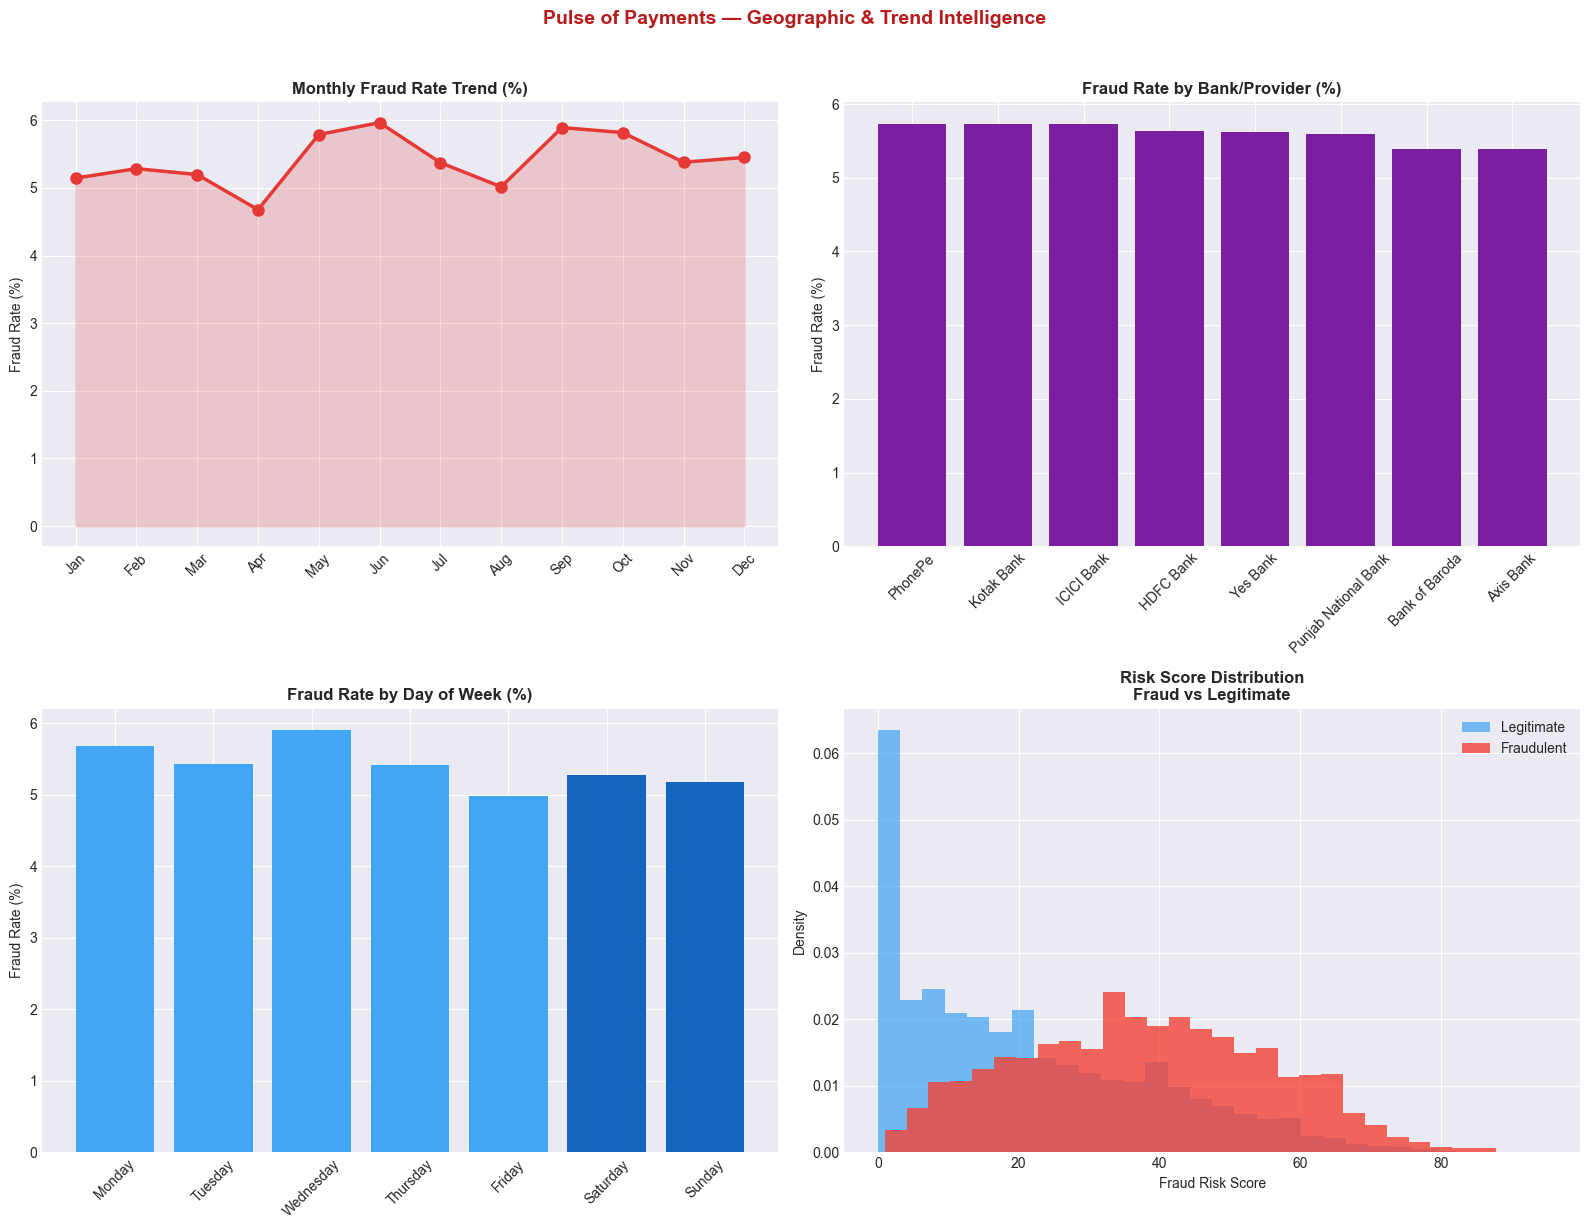

✅ Chart 3 saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1 - Monthly fraud trend
monthly = df.groupby('month').agg(
    total=('fraud_label', 'count'),
    fraud=('fraud_label', 'sum')
).reset_index()
monthly['fraud_rate'] = monthly['fraud']/monthly['total']*100
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])

axes[0,0].plot(monthly['month_name'], monthly['fraud_rate'], 
               marker='o', linewidth=2.5, color='#E53935', markersize=8)
axes[0,0].fill_between(range(len(monthly)), monthly['fraud_rate'], 
                        alpha=0.2, color='#E53935')
axes[0,0].set_title('Monthly Fraud Rate Trend (%)', fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('Fraud Rate (%)')
axes[0,0].set_xticks(range(len(monthly)))
axes[0,0].set_xticklabels(monthly['month_name'], rotation=45)

# Chart 2 - Top banks by fraud
bank_fraud = df.groupby('bank_provider')['fraud_label'].agg(['sum','count'])
bank_fraud['rate'] = bank_fraud['sum']/bank_fraud['count']*100
bank_fraud = bank_fraud.sort_values('rate', ascending=False).head(8)
axes[0,1].bar(bank_fraud.index, bank_fraud['rate'], color='#7B1FA2')
axes[0,1].set_title('Fraud Rate by Bank/Provider (%)', fontweight='bold', fontsize=12)
axes[0,1].set_ylabel('Fraud Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 - Fraud by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_fraud = df.groupby('day_of_week')['fraud_label'].agg(['sum','count'])
day_fraud['rate'] = day_fraud['sum']/day_fraud['count']*100
day_fraud = day_fraud.reindex(day_order)
weekend_colors = ['#1565C0' if d in ['Saturday','Sunday'] else '#42A5F5' 
                  for d in day_order]
axes[1,0].bar(day_order, day_fraud['rate'], color=weekend_colors)
axes[1,0].set_title('Fraud Rate by Day of Week (%)', fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4 - Risk score distribution
axes[1,1].hist(df[df['fraud_label']==0]['fraud_risk_score'], 
               bins=30, alpha=0.6, color='#2196F3', label='Legitimate', density=True)
axes[1,1].hist(df[df['fraud_label']==1]['fraud_risk_score'], 
               bins=30, alpha=0.8, color='#F44336', label='Fraudulent', density=True)
axes[1,1].set_title('Risk Score Distribution\nFraud vs Legitimate', fontweight='bold', fontsize=12)
axes[1,1].set_xlabel('Fraud Risk Score')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()

plt.suptitle('Pulse of Payments — Geographic & Trend Intelligence', 
             fontsize=14, fontweight='bold', color='#B71C1C', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/chart3_geographic_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

In [6]:
import sqlite3

conn = sqlite3.connect('../data/payments_india.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)
print(f"✅ Database created: payments_india.db")
print(f"Table 'transactions' loaded with {len(df):,} rows")
conn.close()

✅ Database created: payments_india.db
Table 'transactions' loaded with 50,000 rows


In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/payments_india.db')

print("="*60)
print("QUERY 1: Fraud Overview by Payment Method")
print("="*60)
q1 = pd.read_sql_query("""
    SELECT payment_method,
           COUNT(*) as total_transactions,
           SUM(fraud_label) as fraud_count,
           ROUND(SUM(fraud_label)*100.0/COUNT(*), 2) as fraud_rate_pct,
           ROUND(AVG(transaction_amount), 2) as avg_amount
    FROM transactions
    GROUP BY payment_method
    ORDER BY fraud_rate_pct DESC
""", conn)
print(q1.to_string(index=False))

print("\n" + "="*60)
print("QUERY 2: Top 5 High Risk Cities")
print("="*60)
q2 = pd.read_sql_query("""
    SELECT city, state,
           COUNT(*) as total,
           SUM(fraud_label) as fraud_count,
           ROUND(SUM(fraud_label)*100.0/COUNT(*), 2) as fraud_rate_pct,
           RANK() OVER (ORDER BY SUM(fraud_label) DESC) as fraud_rank
    FROM transactions
    GROUP BY city, state
    ORDER BY fraud_count DESC
    LIMIT 5
""", conn)
print(q2.to_string(index=False))

print("\n" + "="*60)
print("QUERY 3: Fraud Funnel Analysis")
print("="*60)
q3 = pd.read_sql_query("""
    SELECT investigation_status,
           COUNT(*) as count,
           ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM transactions), 2) as pct_of_total,
           ROUND(AVG(transaction_amount), 2) as avg_amount,
           ROUND(AVG(fraud_risk_score), 2) as avg_risk_score
    FROM transactions
    GROUP BY investigation_status
    ORDER BY count DESC
""", conn)
print(q3.to_string(index=False))

print("\n" + "="*60)
print("QUERY 4: Hourly Fraud Pattern with Running Total (Window Function)")
print("="*60)
q4 = pd.read_sql_query("""
    SELECT hour,
           COUNT(*) as total_transactions,
           SUM(fraud_label) as fraud_count,
           ROUND(SUM(fraud_label)*100.0/COUNT(*), 3) as fraud_rate,
           SUM(SUM(fraud_label)) OVER (ORDER BY hour) as cumulative_fraud,
           CASE
               WHEN hour >= 22 OR hour <= 4 THEN 'HIGH RISK'
               WHEN hour >= 5 AND hour <= 8 THEN 'MEDIUM RISK'
               ELSE 'LOW RISK'
           END as risk_level
    FROM transactions
    GROUP BY hour
    ORDER BY hour
""", conn)
print(q4.to_string(index=False))

print("\n" + "="*60)
print("QUERY 5: Merchant Category Risk Ranking")
print("="*60)
q5 = pd.read_sql_query("""
    SELECT merchant_category,
           COUNT(*) as total,
           SUM(fraud_label) as fraud_count,
           ROUND(SUM(fraud_label)*100.0/COUNT(*), 3) as fraud_rate,
           ROUND(AVG(transaction_amount), 2) as avg_amount,
           RANK() OVER (ORDER BY SUM(fraud_label)*100.0/COUNT(*) DESC) as risk_rank
    FROM transactions
    GROUP BY merchant_category
    ORDER BY fraud_rate DESC
""", conn)
print(q5.to_string(index=False))

print("\n" + "="*60)
print("QUERY 6: Monthly Fraud Trend with Moving Average")
print("="*60)
q6 = pd.read_sql_query("""
    SELECT month,
           COUNT(*) as total_transactions,
           SUM(fraud_label) as fraud_count,
           ROUND(SUM(fraud_label)*100.0/COUNT(*), 3) as fraud_rate,
           ROUND(AVG(SUM(fraud_label)*100.0/COUNT(*)) 
               OVER (ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 3) as moving_avg_3month
    FROM transactions
    GROUP BY month
    ORDER BY month
""", conn)
print(q6.to_string(index=False))

print("\n" + "="*60)
print("QUERY 7: Bank Provider Risk Intelligence")
print("="*60)
q7 = pd.read_sql_query("""
    SELECT bank_provider,
           COUNT(*) as total_transactions,
           SUM(fraud_label) as fraud_count,
           ROUND(SUM(fraud_label)*100.0/COUNT(*), 3) as fraud_rate,
           ROUND(SUM(CASE WHEN fraud_label=1 THEN transaction_amount ELSE 0 END), 2) as total_fraud_amount,
           RANK() OVER (ORDER BY SUM(fraud_label) DESC) as fraud_rank
    FROM transactions
    GROUP BY bank_provider
    ORDER BY fraud_count DESC
""", conn)
print(q7.to_string(index=False))

conn.close()
print("\n✅ ALL SQL QUERIES COMPLETE!")

QUERY 1: Fraud Overview by Payment Method
payment_method  total_transactions  fraud_count  fraud_rate_pct  avg_amount
   Net Banking                5050          470            9.31     4479.79
   Credit Card                9098          753            8.28     2989.10
           UPI               22527          944            4.19      827.12
 Mobile Wallet                3344          139            4.16      577.39
    Debit Card                9981          401            4.02     1192.81

QUERY 2: Top 5 High Risk Cities
     city         state  total  fraud_count  fraud_rate_pct  fraud_rank
  Lucknow Uttar Pradesh   1787          109            6.10           1
 Warangal     Telangana   1616          105            6.50           2
    Surat       Gujarat   1725          104            6.03           3
Ahmedabad       Gujarat   1777          101            5.68           4
     Agra Uttar Pradesh   1691          100            5.91           5

QUERY 3: Fraud Funnel Analysis
inves

In [8]:
sql_content = """
-- ================================================
-- PULSE OF PAYMENTS
-- India Digital Payment Fraud Intelligence
-- SQL Analysis Queries
-- ================================================

-- Query 1: Fraud Overview by Payment Method
SELECT payment_method,
       COUNT(*) as total_transactions,
       SUM(fraud_label) as fraud_count,
       ROUND(SUM(fraud_label)*100.0/COUNT(*), 2) as fraud_rate_pct,
       ROUND(AVG(transaction_amount), 2) as avg_amount
FROM transactions
GROUP BY payment_method
ORDER BY fraud_rate_pct DESC;

-- Query 2: Top High Risk Cities with RANK()
SELECT city, state,
       COUNT(*) as total,
       SUM(fraud_label) as fraud_count,
       ROUND(SUM(fraud_label)*100.0/COUNT(*), 2) as fraud_rate_pct,
       RANK() OVER (ORDER BY SUM(fraud_label) DESC) as fraud_rank
FROM transactions
GROUP BY city, state
ORDER BY fraud_count DESC
LIMIT 10;

-- Query 3: Fraud Investigation Funnel
SELECT investigation_status,
       COUNT(*) as count,
       ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM transactions), 2) as pct_of_total,
       ROUND(AVG(transaction_amount), 2) as avg_amount,
       ROUND(AVG(fraud_risk_score), 2) as avg_risk_score
FROM transactions
GROUP BY investigation_status
ORDER BY count DESC;

-- Query 4: Hourly Fraud Pattern with Running Total
SELECT hour,
       COUNT(*) as total_transactions,
       SUM(fraud_label) as fraud_count,
       ROUND(SUM(fraud_label)*100.0/COUNT(*), 3) as fraud_rate,
       SUM(SUM(fraud_label)) OVER (ORDER BY hour) as cumulative_fraud,
       CASE
           WHEN hour >= 22 OR hour <= 4 THEN 'HIGH RISK'
           WHEN hour >= 5 AND hour <= 8 THEN 'MEDIUM RISK'
           ELSE 'LOW RISK'
       END as risk_level
FROM transactions
GROUP BY hour
ORDER BY hour;

-- Query 5: Merchant Category Risk Ranking
SELECT merchant_category,
       COUNT(*) as total,
       SUM(fraud_label) as fraud_count,
       ROUND(SUM(fraud_label)*100.0/COUNT(*), 3) as fraud_rate,
       RANK() OVER (ORDER BY SUM(fraud_label)*100.0/COUNT(*) DESC) as risk_rank
FROM transactions
GROUP BY merchant_category
ORDER BY fraud_rate DESC;

-- Query 6: Monthly Fraud Trend with 3-Month Moving Average
SELECT month,
       COUNT(*) as total_transactions,
       SUM(fraud_label) as fraud_count,
       ROUND(SUM(fraud_label)*100.0/COUNT(*), 3) as fraud_rate,
       ROUND(AVG(SUM(fraud_label)*100.0/COUNT(*)) 
           OVER (ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 3) as moving_avg_3month
FROM transactions
GROUP BY month
ORDER BY month;

-- Query 7: Bank Provider Risk Intelligence
SELECT bank_provider,
       COUNT(*) as total_transactions,
       SUM(fraud_label) as fraud_count,
       ROUND(SUM(fraud_label)*100.0/COUNT(*), 3) as fraud_rate,
       ROUND(SUM(CASE WHEN fraud_label=1 THEN transaction_amount ELSE 0 END), 2) as total_fraud_amount,
       RANK() OVER (ORDER BY SUM(fraud_label) DESC) as fraud_rank
FROM transactions
GROUP BY bank_provider
ORDER BY fraud_count DESC;
"""

with open('../sql/fraud_analysis.sql', 'w') as f:
    f.write(sql_content)

print("✅ SQL file saved: sql/fraud_analysis.sql")

✅ SQL file saved: sql/fraud_analysis.sql


In [9]:
print("="*60)
print("PULSE OF PAYMENTS — PROJECT SUMMARY")
print("="*60)
print(f"Total transactions: {len(df):,}")
print(f"Fraudulent: {df['fraud_label'].sum():,} ({df['fraud_label'].mean()*100:.2f}%)")
print(f"Cities covered: {df['city'].nunique()}")
print(f"States covered: {df['state'].nunique()}")
print(f"Payment methods: {df['payment_method'].nunique()}")
print(f"Date range: 2023-01-01 to 2024-12-31")
print(f"\nTop fraud city: {df.groupby('city')['fraud_label'].sum().idxmax()}")
print(f"Highest risk payment: {df.groupby('payment_method')['fraud_label'].mean().idxmax()}")
print(f"Peak fraud hour: {df[df['fraud_label']==1]['hour'].mode()[0]}:00")
print(f"\nOutputs saved:")
print("  chart1_fraud_overview.png")
print("  chart2_investigation_funnel.png")
print("  chart3_geographic_trends.png")
print("  payments_india.db")
print("  fraud_analysis.sql")
print("  india_payments_clean.csv")
print("\n✅ PYTHON + SQL PHASE COMPLETE!")
print("NEXT: Build Power BI Dashboard!")

PULSE OF PAYMENTS — PROJECT SUMMARY
Total transactions: 50,000
Fraudulent: 2,707 (5.41%)
Cities covered: 29
States covered: 13
Payment methods: 5
Date range: 2023-01-01 to 2024-12-31

Top fraud city: Lucknow
Highest risk payment: Net Banking
Peak fraud hour: 4:00

Outputs saved:
  chart1_fraud_overview.png
  chart2_investigation_funnel.png
  chart3_geographic_trends.png
  payments_india.db
  fraud_analysis.sql
  india_payments_clean.csv

✅ PYTHON + SQL PHASE COMPLETE!
NEXT: Build Power BI Dashboard!
